### <span style = "color: rgba(216, 221, 228, 1);">Análisis diagnóstico de factores de riesgo y rendimiento estudiantil</span>📊

### EDA (Exploratory and Data Analysis) 🔎

### 1. Modelo Relacional E-R
<img src = "https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F1880515%2F864453733ec7cb92f003450ed38a2144%2FScreen%20Shot%202020-01-11%20at%208.41.59%20pm.png?generation=1578735825723455&alt=media">

#### 2. Dataset Description
<iframe src="https://www.kaggle.com/embed/yousefalbasel/oulad-personalized-learning-path-recommender-sys?cellIds=3&kernelSessionId=196889485" height="300" style="margin: 0 auto; width: 100%; max-width: 950px;" frameborder="0" scrolling="auto" title="OULAD Personalized Learning Path | Recommender Sys"></iframe>

#### 3. Importación de módulos y lectura de datos

Fase 1: Adquisición y preparación de la base

1.1 Carga e integración: Cargar las 7 tablas del modelo E-R en Python (Pandas).

In [63]:
import pandas as pd
#Importar  data desde csv
df_assessments= pd.read_csv(r"C:\Users\jprom\Desktop\IT Academy\Proyecto Final\data_set_project\assessments.csv")
df_courses = pd.read_csv(r"C:\Users\jprom\Desktop\IT Academy\Proyecto Final\data_set_project\courses.csv")
df_studentAssessment = pd.read_csv(r"C:\Users\jprom\Desktop\IT Academy\Proyecto Final\data_set_project\studentAssessment.csv")
df_studentInfo = pd.read_csv(r"C:\Users\jprom\Desktop\IT Academy\Proyecto Final\data_set_project\studentInfo.csv")
df_studentRegistration = pd.read_csv(r"C:\Users\jprom\Desktop\IT Academy\Proyecto Final\data_set_project\studentRegistration.csv")
df_studentVle = pd.read_csv(r"C:\Users\jprom\Desktop\IT Academy\Proyecto Final\data_set_project\studentVle.csv")
df_vle = pd.read_csv(r"C:\Users\jprom\Desktop\IT Academy\Proyecto Final\data_set_project\vle.csv")


In [64]:
#Importar librerias
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1.2 Definición de la base de datos:

* Crear la variable objetivo binaria: Éxito (1) (Pass/Distinttion) vs. Riesgo (0) (Fail/Withdrawn).


Tarea preliminar: Identificar la columna original

Columna de origen: La variable original que se va a transformar es final_result de la tabla studentInfo.

Valores originales: (Pass / Distinction / Fail / Withdrawn)

Ingeniería de variables objetivo ($\text{Y}$)

In [65]:
#1. Inicializar Columnas
# La nueva columna risk_class se crea en el DataFrame studentInfo y se inicializa con un valor temporal o nulo.
df_studentInfo['risk_class'] = np.nan
#2. Definir  Success Class (1)
df_studentInfo.loc[df_studentInfo['final_result'].isin(['Pass', 'Distinction']), 'risk_class'] = 1
#3. Definir  Risk Class (0)
df_studentInfo.loc[df_studentInfo['final_result'].isin(['Fail', 'Withdrawn']), 'risk_class'] = 0
#4. Comprobar la salida para verificar posibles valores nulos
df_studentInfo['risk_class'].value_counts()
#df_studentInfo['id_student'].count()

risk_class
0.0    17208
1.0    15385
Name: count, dtype: int64

In [66]:
df_studentInfo.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,risk_class
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,0.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,1.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1.0


* Crear la tabla base uniendo studentInfo y courses. Esta será la unidad principal de análisis  (Student-Module-Presentation). Master Data Base (Demographic Data and Context).

In [67]:
# Merge studentInfo with Courses lengths (match both module and presentation)
df_base = df_studentInfo.merge(
	df_courses[['code_module', 'code_presentation', 'module_presentation_length']],
	on=['code_module', 'code_presentation'],
	how='left'
)

df_base.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,risk_class,module_presentation_length
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1.0,268
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1.0,268
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,0.0,268
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,1.0,268
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1.0,268


Fase 2: Ingeniería de Funcionalidades Esenciales

2.1: Agregación Simplificada del Rendimiento ($\text{X}_{\text{Rendimiento}}$)

2.1.1 Filtrar y ordenar la tabla de evaluaciones de estudiantes para incluir solo las evaluaciones más antiguas (usando la columna de fecha en la tabla de evaluaciones). Ordenar los datos por estudiante, módulo y fecha ascendente.

Combinación de la evaluación de estudiantes con las evaluaciones: Necesitamos la tabla de evaluaciones para conocer la ponderación y la secuencia (fecha) de las evaluaciones.

In [68]:
df_performance = df_studentAssessment.merge(
    df_assessments, 
    on='id_assessment', 
    how='inner'
)
# Convert evaluation dates from df_assessments['date'] into numeric, coerce non-numeric to NaN, then fill NaN and convert to integer
df_performance['date'] = pd.to_numeric(df_performance['date'], errors='coerce').fillna(0).astype(int)
df_performance.head()

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19,10.0
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19,10.0
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19,10.0
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19,10.0
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19,10.0


Ordenar y filtrar por primeras evaluaciones: Agrupar por estudiante-curso, ordenar por fecha de evaluación y seleccionar solo las 2 primeras.

In [69]:
# Ordenar las evaluaciones por estudiante, curso y fecha de evaluación
df_performance_sorted = df_performance.sort_values(
    ['id_student', 'code_module', 'code_presentation', 'date']
).reset_index(drop=True)

# Filtrar solo las dos primeras evaluaciones (por estudiante y curso)
df_top2_scores = df_performance_sorted.groupby(
    ['id_student', 'code_module', 'code_presentation']
).head(2)


In [70]:
df_performance_sorted.head()

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
0,1758,6516,17,0,60.0,AAA,2014J,TMA,19,10.0
1,1759,6516,51,0,48.0,AAA,2014J,TMA,54,20.0
2,1760,6516,116,0,63.0,AAA,2014J,TMA,117,20.0
3,1761,6516,164,0,61.0,AAA,2014J,TMA,166,20.0
4,1762,6516,210,0,77.0,AAA,2014J,TMA,215,30.0


In [71]:
df_top2_scores.head()

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
0,1758,6516,17,0,60.0,AAA,2014J,TMA,19,10.0
1,1759,6516,51,0,48.0,AAA,2014J,TMA,54,20.0
5,25348,8462,29,0,93.0,DDD,2013J,TMA,25,10.0
6,25349,8462,51,0,83.0,DDD,2013J,TMA,53,12.5
8,25362,8462,-1,1,93.0,DDD,2014J,TMA,20,5.0


Calcular las métricas de rendimiento: Agrupar los resultados de las dos primeras evaluaciones.

In [72]:
df_X_performance = df_top2_scores.groupby(
    ['id_student', 'code_module', 'code_presentation']
).agg(
    # Average score of two first evaluations
    avg_initial_score=('score', 'mean'),
    # Score of first evaluation (use 'first' after sorted)
    first_eval_score=('score', 'first')
).reset_index()

In [73]:
df_X_performance.head()

,id_student,code_module,code_presentation,avg_initial_score,first_eval_score
0,6516,AAA,2014J,54.0,60.0
1,8462,DDD,2013J,88.0,93.0
2,8462,DDD,2014J,88.0,93.0
3,11391,AAA,2013J,81.5,78.0
4,23629,BBB,2013B,65.0,67.0


Tarea 2.2: Agregación de comportamiento (behavior) global ($\text{X}_{\text{Behavior}}$)

Objetivo: Medir la intensidad de la interacción del estudiante con el VLE (Virtual Learning Environment).

In [74]:
# Use df_StudentVle directly to aggregation, with date
df_behavior = df_studentVle.copy()

In [75]:
df_behavior.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


Calcular métricas de comportamiento: Agrupar por estudiante-curso.

In [76]:
df_X_behavior = df_behavior.groupby(
    ['id_student', 'code_module', 'code_presentation']
).agg(
    # 1. Total de clics acumulados
    total_clicks_acum=('sum_click', 'sum'),
    # 2. Total de días de actividad (conteo de fechas únicas)
    total_active_days=('date', 'nunique')
).reset_index()

In [77]:
df_X_behavior.head()

,id_student,code_module,code_presentation,total_clicks_acum,total_active_days
0,6516,AAA,2014J,2791,159
1,8462,DDD,2013J,646,56
2,8462,DDD,2014J,10,1
3,11391,AAA,2013J,934,40
4,23629,BBB,2013B,161,16


Tarea 2.3: Objetivo de consolidación final:

Integrar todas las funciones creadas ($\text{X}_{\text{Performance}}$ and $\text{X}_{\text{Behavior}}$) en el Master Data Base (df_base)

Performance Union ($\text{X}_{\text{Performance}}$): Unir df_X_performance al df_base.

In [78]:
df_base = df_base.merge(
    df_X_performance, 
    on=['id_student', 'code_module', 'code_presentation'], 
    how='left'
)

Behavior Union ($\text{X}_{\text{Behavior}}$): Unir df_X_behavior al DF base

In [79]:
df_base = df_base.merge(
    df_X_behavior, 
    on=['id_student', 'code_module', 'code_presentation'], 
    how='left'
)

Tratamiento de valores nulos tras la unión: Los estudiantes sin actividad en el entorno virtual de aprendizaje (VLE) ni evaluaciones entregadas tendrán valores nulos (NaN) en las nuevas columnas. Debemos imputar estos valores nulos a cero (0), ya que un NaN en 'total_clicks_acum' significa que el estudiante no realizó ningún clic.

In [80]:
# Fills NaNs with 0 to new metrics (asuming 0 activity/score)
df_base['avg_initial_score'] = df_base['avg_initial_score'].fillna(0)
df_base['first_eval_score'] = df_base['first_eval_score'].fillna(0)
df_base['total_clicks_acum'] = df_base['total_clicks_acum'].fillna(0)
df_base['total_active_days'] = df_base['total_active_days'].fillna(0)



In [81]:
df_base

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,risk_class,module_presentation_length,avg_initial_score,first_eval_score,total_clicks_acum,total_active_days
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1.0,268,81.5,78.0,934.0,40.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1.0,268,69.0,70.0,1435.0,80.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,0.0,268,0.0,0.0,281.0,12.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,1.0,268,71.5,72.0,2158.0,123.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1.0,268,49.5,69.0,1034.0,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20%,0-35,0,30,N,Fail,0.0,269,0.0,0.0,41.0,5.0
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction,1.0,269,80.5,80.0,893.0,45.0
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass,1.0,269,70.0,65.0,312.0,24.0
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn,0.0,269,91.5,83.0,275.0,13.0


In [82]:
#Chequeamos valores nulos en las columnas del df_base
columnas_con_nulos = df_base.isnull().sum()
columnas_con_nulos[columnas_con_nulos > 0]


imd_band    1111
dtype: int64

El índice imd_band especifica el nivel de privación múltiple del lugar donde residía el estudiante durante la presentación del módulo.

Lo completaremos según el nivel más frecuente para esa región.

In [83]:
regions_list = df_base[df_base['imd_band'].isnull()]['region'].unique()

for region in regions_list:
  mode_imd_band = df_base[df_base['region'] == region]['imd_band'].mode()[0]
  df_base.loc[(df_base['imd_band'].isnull()) & (df_base['region'] == region), 'imd_band'] = mode_imd_band

Descripción estadística

In [84]:
df_base.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id_student,32593.0,706687.669131,549167.313855,3733.0,508573.0,590310.0,644453.0,2716795.0
num_of_prev_attempts,32593.0,0.163225,0.479758,0.0,0.0,0.0,0.0,6.0
studied_credits,32593.0,79.758691,41.071900,30.0,60.0,60.0,120.0,655.0
risk_class,32593.0,0.472034,0.499225,0.0,0.0,0.0,1.0,1.0
module_presentation_length,32593.0,256.010125,13.179078,234.0,241.0,262.0,268.0,269.0
avg_initial_score,32593.0,56.856825,33.015478,0.0,38.0,69.0,82.0,100.0
first_eval_score,32593.0,56.685730,34.875965,0.0,30.0,70.0,84.0,100.0
total_clicks_acum,32593.0,1215.141257,1692.604449,0.0,142.0,602.0,1585.0,24139.0
total_active_days,32593.0,55.475685,54.515290,0.0,11.0,40.0,85.0,286.0


### Outputs



La puntuación oscila entre 0 y 100, con una media de 57 y una desviación estándar con una variabilidad significativa(aproximadamente 35), lo que indica que la mayoría de las puntuaciones están dispersas y bastante lejos de la media.

La mayoría de los estudiantes no han realizado ningún intento previo (los percentiles 25, 50 y 75 son 0), pero el número máximo de intentos previos es de 6. Los créditos cursados ​​varían de 0 a 630, con una media de casi 80, y el 50 % de los estudiantes cursó menos de 90 créditos.

---------------------------------------------------------------------------------------------------------------------

### Análisis Diagnóstico & Visualizaciones

Fase 3: Análisis diagnóstico y visualización

El enfoque se centra en el impacto de las variables demográficas y las características esenciales creadas.

In [85]:
# Basic configuration to grafics 
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100 # Improve the grafics resolution

3.1. Distribución de datos categóricos


In [86]:
df_cat = df_base.select_dtypes(exclude=np.number)

Visualización: Plots por variables Categoricas


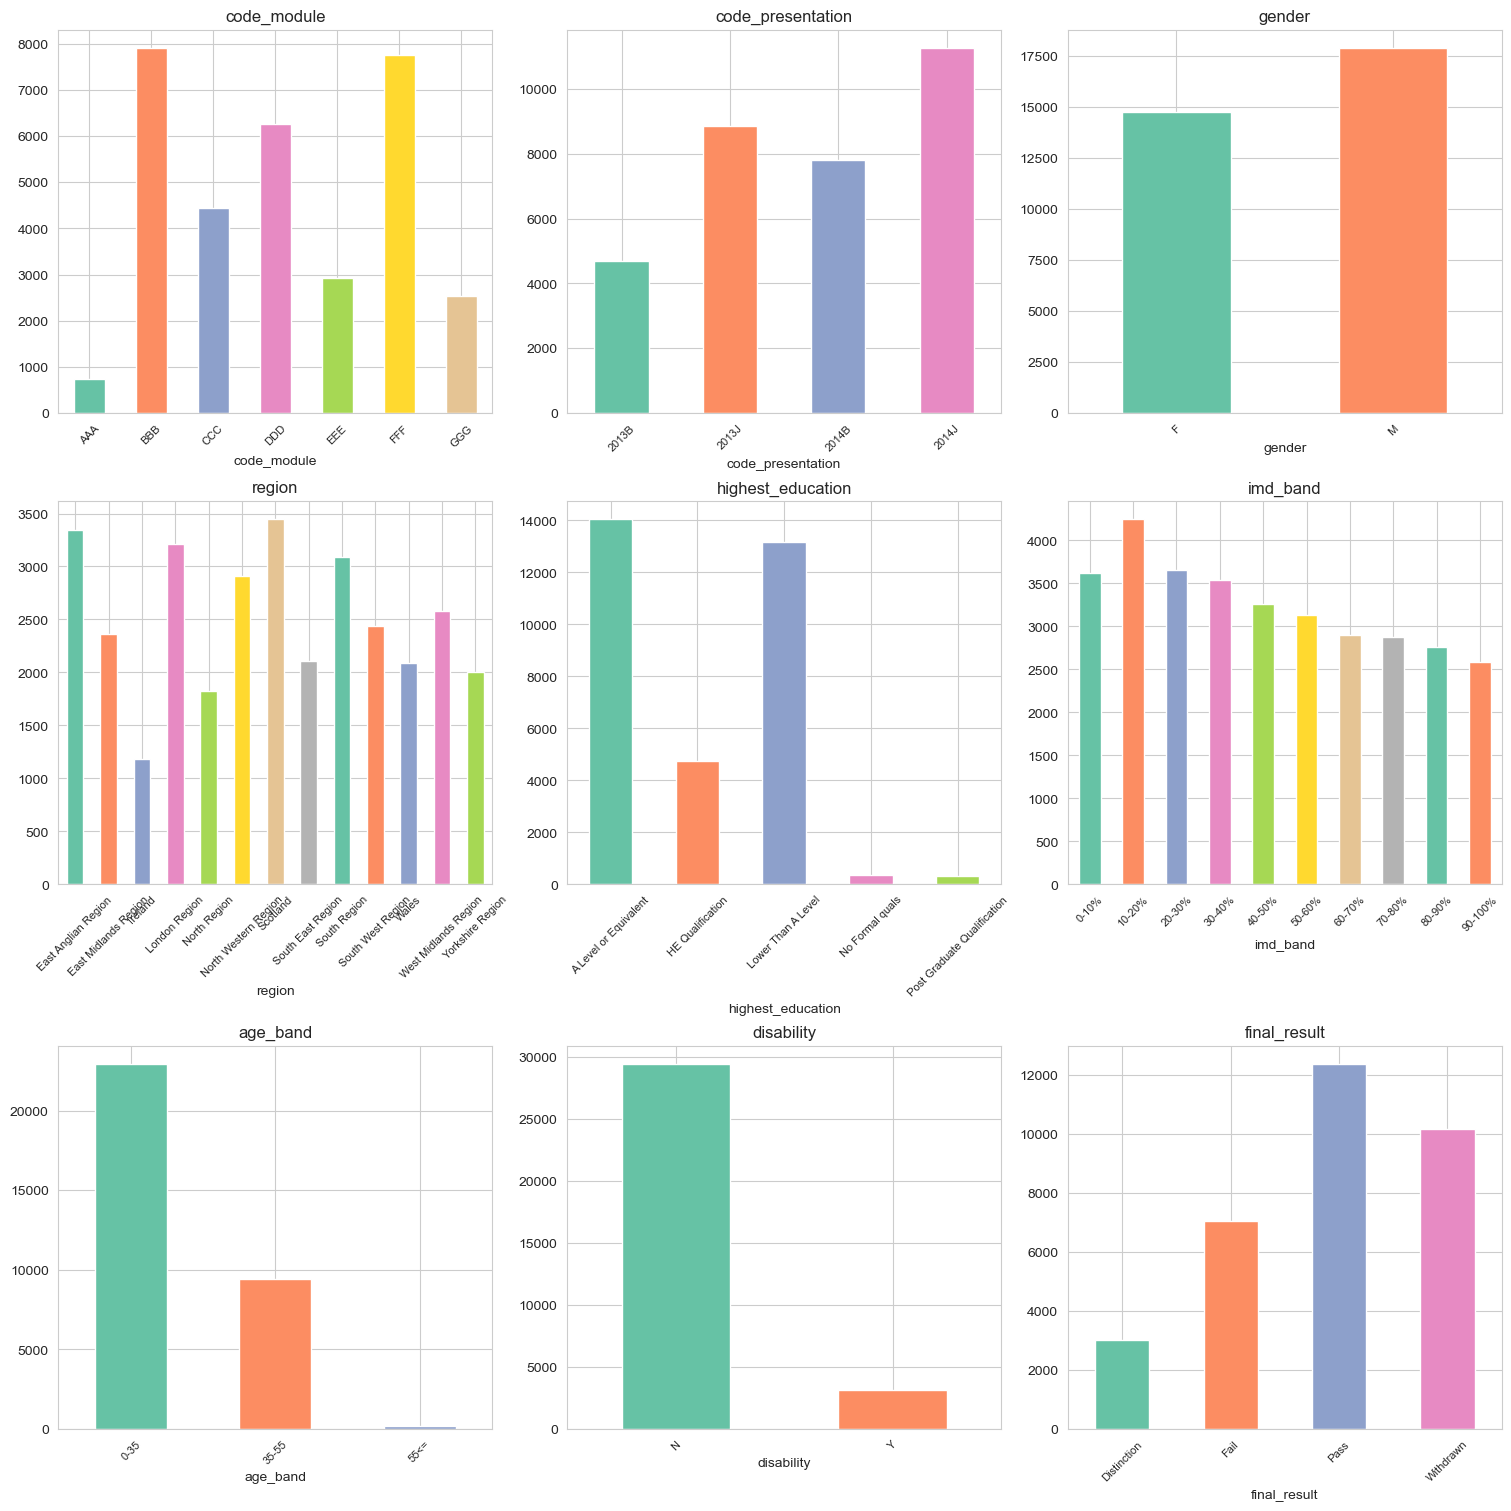

In [88]:
num_cols = 3  # Número de columnas en la cuadrícula
num_rows = (len(df_cat.columns) + num_cols - 1) // num_cols

# Crea los subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows), constrained_layout=True)
axes = axes.flatten()

# Se usa un color fijo o una paleta de colores para todos los plots
palette = sns.color_palette("Set2")

for i, col in enumerate(df_cat.columns):
    # 1. Calcula los value counts
    counts = df_cat[col].value_counts()
    
    # 2. Ordena el índice (las categorías) alfabéticamente/categóricamente
    # Si la categoría es numérica o tiene un orden lógico (como "imd_band"), 
    # usar sort_index() suele funcionar. Para órdenes específicos, 
    # consulta la sección de Notas.
    counts_sorted = counts.sort_index()
    
    # 3. Grafica usando el DataFrame/Series ordenado
    # Se selecciona un solo color o se repite la paleta para las barras
    color_to_use = [palette[j % len(palette)] for j in range(len(counts_sorted))]
    
    counts_sorted.plot(kind='bar', ax=axes[i], color=color_to_use)
    
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)

# Eliminar subplots vacíos
for j in range(len(df_cat.columns), len(axes)):
    fig.delaxes(axes[j])

plt.show()

### Insights

* Muy pocos estudiantes sin educación formal.

* Muy pocos estudiantes con estudios de posgrado.

* Los estudiantes provienen de diversas regiones del Reino Unido, Escocia, Irlanda y Gales. Escocia, individualmente, cuenta con el mayor número de estudiantes. Irlanda tiene el menor número. La mayoría de los estudiantes provienen de diversas regiones de Inglaterra, representando casi el 80 %.

* En el gráfico de barras anterior, se observa la distribución de los estudiantes por nivel socioeconómico (NSE). Muchos estudiantes parecen provenir de zonas más desfavorecidas, con un pico en el rango del 10-20 %.

* La distribución por género es bastante equitativa, con una ligera sobrerrepresentación de hombres en la muestra estudiantil.

* En cuanto a la distribución de estudiantes con y sin discapacidad, se observa que menos del 10 % de los estudiantes se identifican con alguna discapacidad, por lo que están subrepresentados en este grupo.

* Como se puede apreciar, la mayoría de los estudiantes obtienen resultados negativos, como la retirada o el suspenso, mientras que más del 50 % obtiene un resultado positivo, como aprobar o aprobar con distinción.

---------------------------------------------------------------------------------------------------------------------

Visualización: Tasa de riesgo por género

* Objetivo: Comparar la distribución de la variable binaria objetivo (risk_class) para cada valor de la variable (gender) ('M' y 'F'), revelando si un género presenta una tasa de fracaso/abandono significativamente mayor.

In [89]:
# 1. Calcular el conteo de Éxito/Riesgo por Género
df_gender_counts = df_base.groupby(['gender', 'risk_class']).size().reset_index(name='count')

# 2. Calcular la proporción (Normalización) dentro de cada género
# El 'transform' calcula el total de estudiantes por cada género.
df_gender_counts['total_x_gender'] = df_gender_counts.groupby('gender')['count'].transform('sum')

# 3. Calcular el porcentaje
df_gender_counts['percentage'] = (df_gender_counts['count'] / df_gender_counts['total_x_gender']) * 100

# 4. Asignar etiquetas claras para la visualización
df_gender_counts['Result'] = df_gender_counts['risk_class'].map({1: 'Success (Pass/Distinction)', 0: 'Risk (Fail/Withdrawn)'})



Creación del gráfico de barras agrupadas

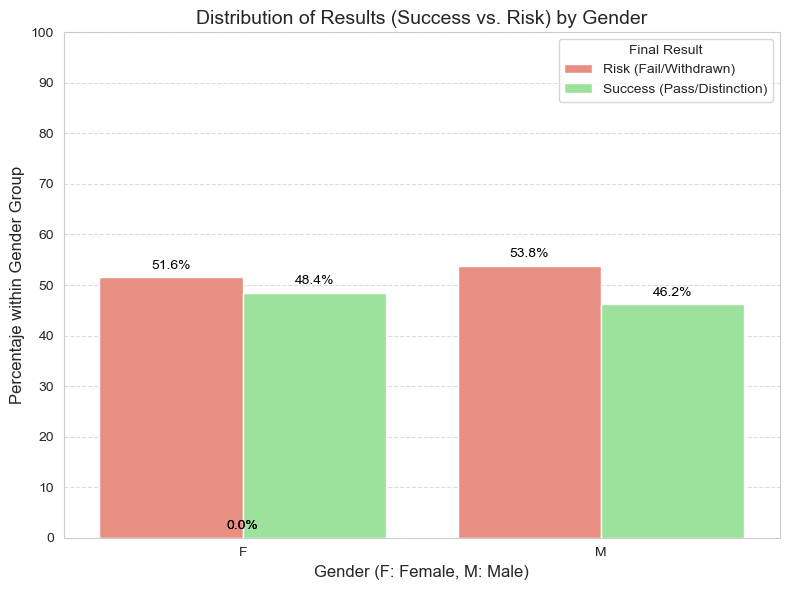

In [90]:
# Configuración del gráfico 
plt.figure(figsize=(8, 6))

# Crear el gráfico de barras agrupadas y normalizadas y obtener el eje para anotaciones
ax = sns.barplot(
    data=df_gender_counts,
    x='gender',             # Género en el eje X
    y='percentage',         # Porcentaje en el eje Y
    hue='Result',           # El color (hue) diferenciará Éxito vs. Riesgo
    palette={
        'Success (Pass/Distinction)': 'lightgreen',
        'Risk (Fail/Withdrawn)': 'salmon'
    }
)

# Añadir etiquetas de valor a las barras usando las 'patches' de matplotlib
for p in ax.patches:
    height = p.get_height() # type: ignore
    if np.isnan(height):
        continue
    ax.annotate(
        f"{height:.1f}%",
        xy=(p.get_x() + p.get_width() / 2., height), # type: ignore
        xytext=(0, 4),            # desplazamiento en puntos para que el texto quede por encima de la barra
        textcoords="offset points",
        ha="center",
        va="bottom",
        color="black",
        size=10
    )

# Title and tags 
plt.title('Distribution of Results (Success vs. Risk) by Gender', fontsize=14)
plt.xlabel('Gender (F: Female, M: Male)', fontsize=12)
plt.ylabel('Percentaje within Gender Group', fontsize=12)
plt.yticks(range(0, 101, 10))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Final Result')
plt.tight_layout()
plt.show()

---------------------------------------------------------------------------------------------------------------------

Visualización: Gráfico de barras normalizado por clase del impacto demográfico: Y vs. nivel educativo más alto, Y vs. banda de privación.

* Objetivo: Mostrar cómo varía la tasa de riesgo (Y = 0) entre los niveles de educación previa (nivel educativo más alto) y el índice de privación (banda de privación).

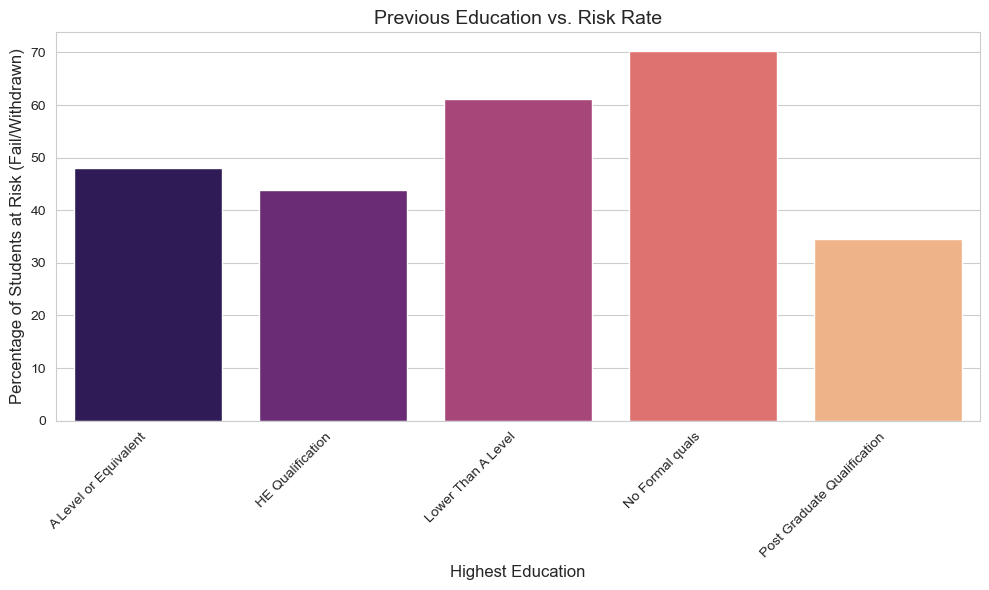

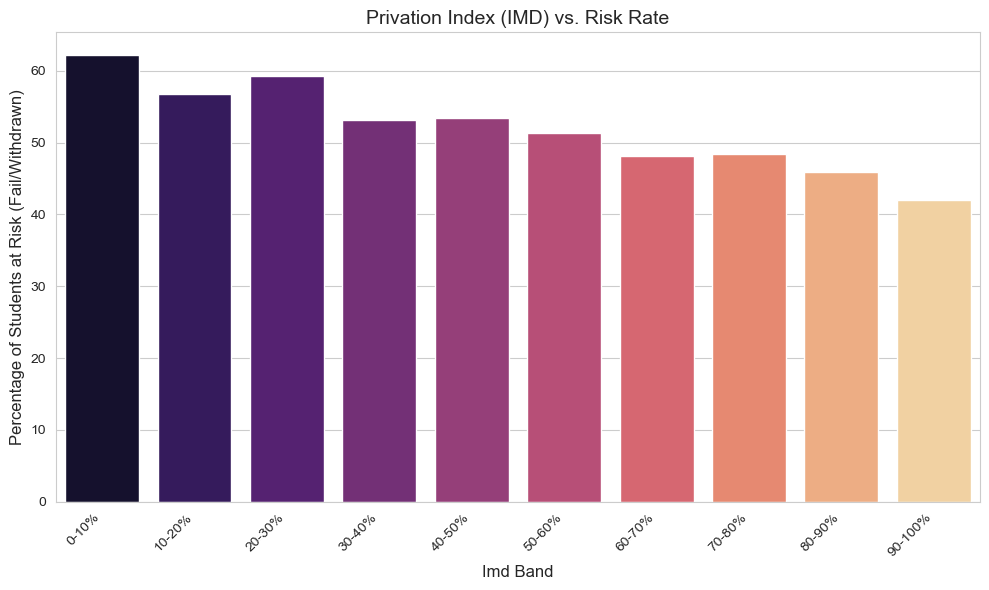

In [99]:
def plot_normalized_risk(df, feature, title):
    """Calcula y grafica la tasa de riesgo (clase_riesgo=0) normalizada por la feature."""
    # 1. Calcular proporciones (normalizar por índice)
    df_counts = df.groupby([feature, 'risk_class']).size().unstack(fill_value=0)
    df_proportions = df_counts.div(df_counts.sum(axis=1), axis=0) * 100

    # 2. Seleccionar la tasa de riesgo (clase_riesgo=0)
    # Asegurarse de que la columna exista (0 corresponde a risk_class==0)
    df_risk_rate = df_proportions.reset_index()
    if 0 not in df_risk_rate.columns:
        df_risk_rate[0] = 0.0
    df_risk_rate = df_risk_rate[[feature, 0]]
    df_risk_rate.rename(columns={0: 'Risk_Rate (%)'}, inplace=True)
    
    # Convertir posibles NaNs en strings para evitar problemas al graficar categorías
    df_risk_rate[feature] = df_risk_rate[feature].fillna('Missing').astype(str)
    
    # 3. Graficar (sin hue porque 'highest_education' no está en df_risk_rate salvo cuando feature==that)
    plt.figure(figsize=(10, 6))
    df_sorted = df_risk_rate.sort_index (ascending=True)
    sns.barplot(
        x=feature, 
        y='Risk_Rate (%)', 
        data=df_sorted,
        #order=df_sorted.values.tolist(),
        palette='magma',
        hue=feature,
        legend=False
    )
    plt.title(f'{title} vs. Risk Rate', fontsize=14)
    plt.ylabel('Percentage of Students at Risk (Fail/Withdrawn)', fontsize=12)
    plt.xlabel(feature.replace('_', ' ').title(), fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# ----------------- Ejecución -----------------
# 1. highest_education
plot_normalized_risk(df_base, 'highest_education', 'Previous Education')

# 2. imd_band
plot_normalized_risk(df_base, 'imd_band', 'Privation Index (IMD)')

---------------------------------------------------------------------------------------------------------------------

Visualización: Behavior vs. Outcome: VLE Activity

* Objetivo: Determinar si la actividad del entorno virtual de aprendizaje (total_clicks_acumulativo) presenta una diferencia estadísticamente o visualmente significativa entre los grupos de éxito y riesgo.

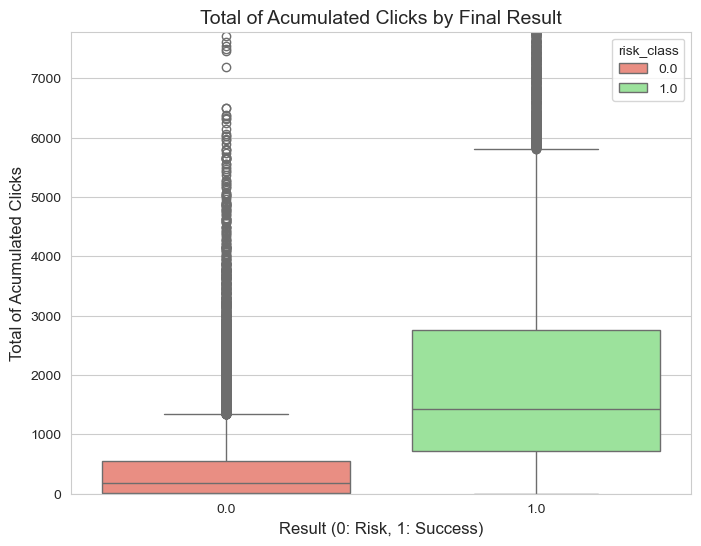

In [124]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x='risk_class', 
    y='total_clicks_acum', 
    data=df_base,
    hue= 'risk_class',
    palette={1.0: 'lightgreen', 0.0: 'salmon'},
    whis= 1.5,
    order=[0.0, 1.0]  # Show Risk (0) first, then Success (1)
)

# Tags
plt.title('Total of Acumulated Clicks by Final Result', fontsize=14)
plt.xlabel('Result (0: Risk, 1: Success)', fontsize=12)
plt.ylabel('Total of Acumulated Clicks', fontsize=12)
plt.ylim(0, df_base['total_clicks_acum'].quantile(0.99))  # Limit the Y axis, to handle outliers 
plt.show()

---------------------------------------------------------------------------------------------------------------------

Visualización: Early Performance (First Score Distribution)

* Objetivo: Visualizar el primer umbral de puntuación de evaluación que separa a los estudiantes del Éxito del Riesgo.

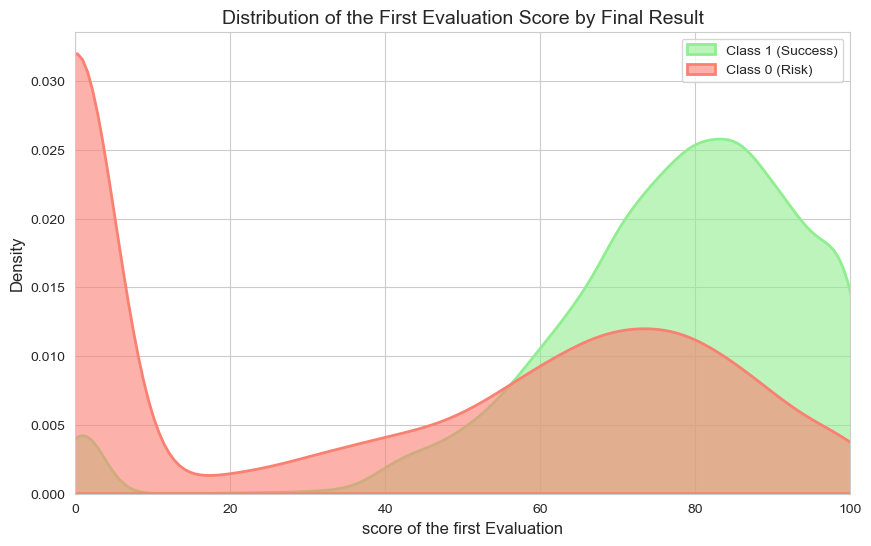

In [101]:
plt.figure(figsize=(10, 6))

# Trazar la distribución del first_eval_score para la Clase 1 (Éxito)
sns.kdeplot(
    data=df_base[df_base['risk_class'] == 1],
    x='first_eval_score',
    label='Class 1 (Success)', 
    fill=True, 
    color='lightgreen', 
    alpha=0.6,
    linewidth=2
)

# Trazar la distribución del first_eval_score para la Clase 0 (Riesgo)
sns.kdeplot(
    data=df_base[df_base['risk_class'] == 0],
    x='first_eval_score',
    label='Class 0 (Risk)', 
    fill=True, 
    color='salmon', 
    alpha=0.6,
    linewidth=2
)

# Etiquetas
plt.title('Distribution of the First Evaluation Score by Final Result', fontsize=14)
plt.xlabel('score of the first Evaluation', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.xlim(0, 100) # El score generalmente va de 0 a 100
plt.show()

---------------------------------------------------------------------------------------------------------------------

Visualización: Exploring Correlations: Heatmap

* Objetivo: Cuantificar la relación lineal entre numerical features y final result ($\text{Y}$).

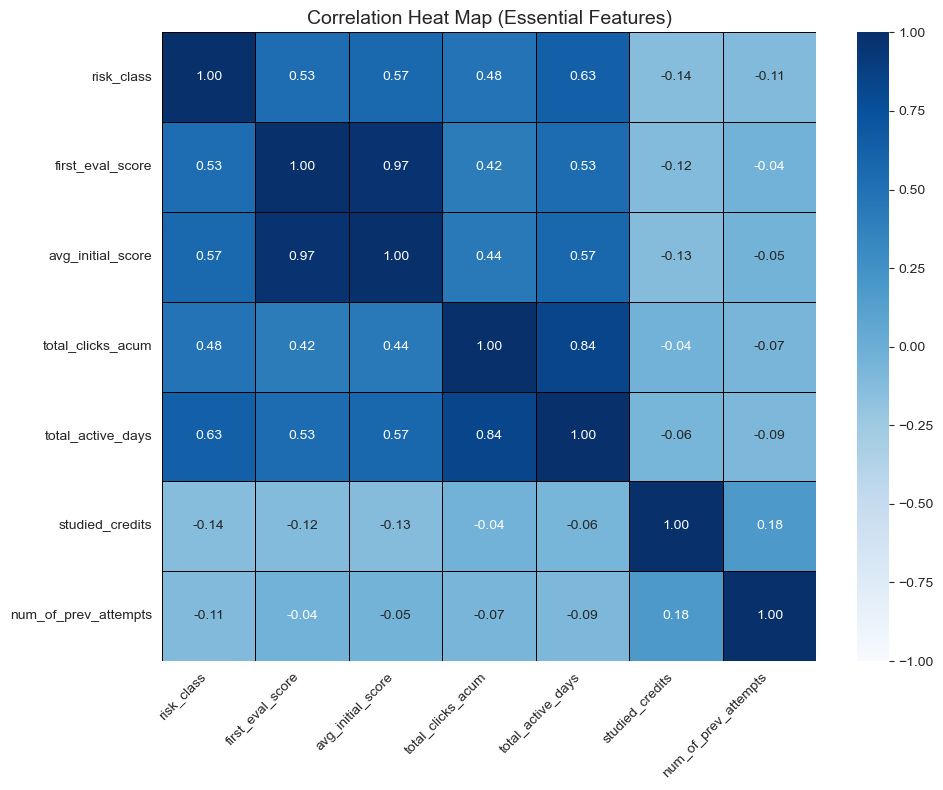


Correlaciones con la Clase de Riesgo (1 = Éxito):


risk_class              1.000000
total_active_days       0.625964
avg_initial_score       0.569221
first_eval_score        0.528452
total_clicks_acum       0.476574
num_of_prev_attempts   -0.105460
studied_credits        -0.138630
Name: risk_class, dtype: float64

In [102]:
# 1. Seleccionar las variables numéricas esenciales para la matriz de correlación
numeric_features = [
    'risk_class',
    'first_eval_score',
    'avg_initial_score',
    'total_clicks_acum',
    'total_active_days',
    'studied_credits',
    'num_of_prev_attempts'
]

# 2. Calcular la matriz de correlación
df_corr = df_base[numeric_features].corr()

# 3. Graficar el Mapa de Calor
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_corr,
    annot=True, # Mostrar los valores de correlación
    fmt=".2f", # Formato con dos decimales
    cmap='Blues', # Esquema de color: blanco (negativo) a azul (positivo)
    cbar=True,
    linewidths=0.5,
    linecolor='black',  vmin = -1, vmax = 1
)

plt.title('Correlation Heat Map (Essential Features)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Encontrar las correlaciones más fuertes con la variable objetivo
print("\nCorrelaciones con la Clase de Riesgo (1 = Éxito):")
df_strong_corr=df_corr['risk_class'].sort_values(ascending=False)
df_strong_corr

---------------------------------------------------------------------------------------------------------------------

Visualización: Serie temporal de clics acumulados por resultado

* Objetivo: Generar una curva de tendencia que muestre si la actividad total de los estudiantes en la clase de Risk (0) es consistentemente menor y se estabiliza antes que la de los estudiantes en la clase de Success (1).

1. Preparación y etiquetado de datos: 

El primer paso consiste en combinar la actividad de clics detallada (df_StudentVle) con el resultado final del estudiante (class_risk) y convertir el día (date) a la semana del curso.

In [34]:
# 1. Unir la actividad granular (df_StudentVle) con el resultado final (risk_class)
df_activity = df_studentVle.merge(
    df_base[['id_student', 'code_module', 'code_presentation', 'risk_class']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

# 2. Calcular la Semana del Curso
# Se asume que 'date' es el número de días desde el inicio.
# (día // 7) + 1 para obtener la semana.
df_activity['semana_curso'] = (df_activity['date'] // 7) + 1

# 3. Limpieza: Eliminar cualquier NaN que pueda haber quedado si df_StudentVle tenía estudiantes no registrados
df_activity.dropna(subset=['risk_class'], inplace=True)

2. Agregación semanal y total acumulado: 

Agregamos los clics por semana para cada grupo de resultados y luego calculamos el total acumulado.

In [35]:
# 1. Agrupar la actividad total por Semana y por Resultado (Éxito vs. Riesgo)
df_weekly_clicks = df_activity.groupby(
    ['semana_curso', 'risk_class']
)['sum_click'].sum().reset_index()

# 2. Calcular la Suma Acumulada (CLAVE DEL GRÁFICO)
# Se usa groupby().cumsum() para que la suma acumulada se calcule por separado para cada grupo de resultado.
df_weekly_clicks['clicks_acumulados'] = df_weekly_clicks.groupby('risk_class')[
    'sum_click'
].cumsum()

# 3. Preparar etiquetas
df_weekly_clicks['Result'] = df_weekly_clicks['risk_class'].map({
    1.0: 'Success (Pass/Distinction)', 
    0.0: 'Risk (Fail/Withdrawn)'
})

df_weekly_clicks.head()

,semana_curso,risk_class,sum_click,clicks_acumulados,Result
0,-3,0.0,12354,12354,Risk (Fail/Withdrawn)
1,-3,1.0,30944,30944,Success (Pass/Distinction)
2,-2,0.0,146151,158505,Risk (Fail/Withdrawn)
3,-2,1.0,287256,318200,Success (Pass/Distinction)
4,-1,0.0,206596,365101,Risk (Fail/Withdrawn)


3. Visualización de series temporales

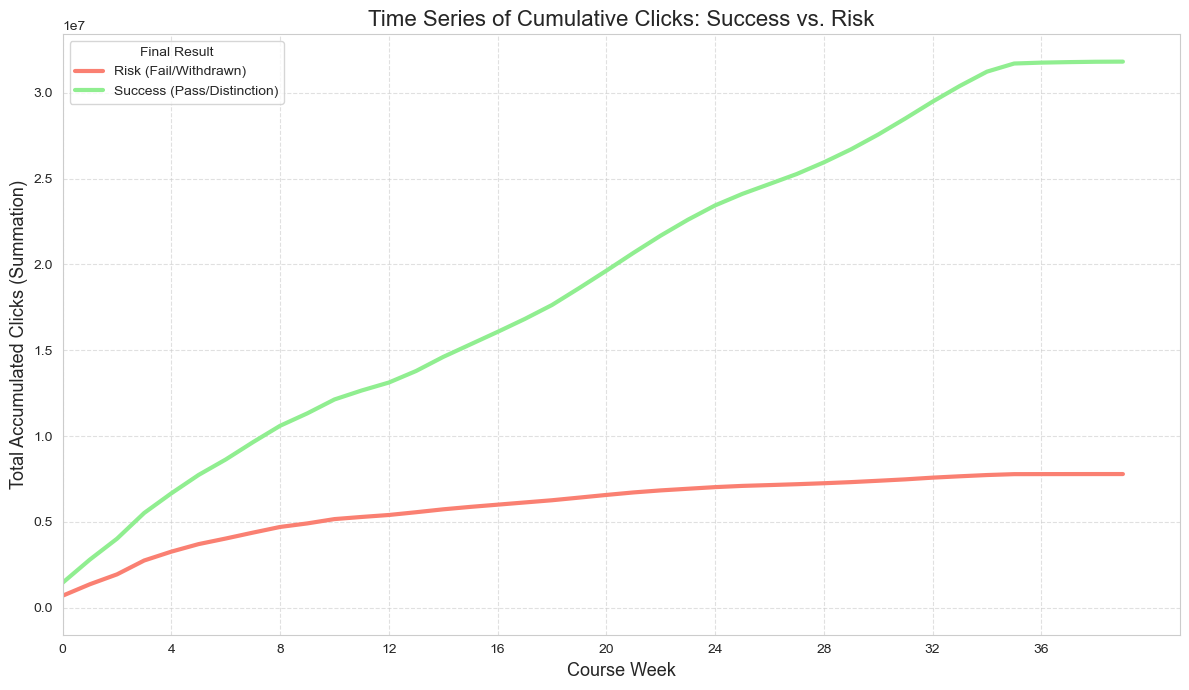

In [36]:
plt.figure(figsize=(12, 7))

sns.lineplot(
    data=df_weekly_clicks,
    x='semana_curso',
    y='clicks_acumulados',
    hue='Result', # Separa las líneas por la clase de resultado
    palette={
        'Success (Pass/Distinction)': 'lightgreen',
        'Risk (Fail/Withdrawn)': 'salmon'
    },
    linewidth=3
)

# Etiquetas y Título
plt.title('Time Series of Cumulative Clicks: Success vs. Risk', fontsize=16)
plt.xlabel('Course Week', fontsize=13)
plt.ylabel('Total Accumulated Clicks (Summation)', fontsize=13)
plt.xlim(0) # Empezar desde la semana 1
plt.xticks(np.arange(0, df_weekly_clicks['semana_curso'].max() + 1, 4)) # Marcar cada 4 semanas
plt.legend(title='Final Result', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---------------------------------------------------------------------------------------------------------------------

Visualización: Tasa de riesgo por grupo de edad

* Objetivo: Determinar si ciertos grupos de edad (age_band) presentan una tasa de riesgo significativamente mayor o menor que otros, lo que indicaría una relación entre la edad y el éxito académico.

1. Preparación de datos (Cálculo de proporciones)

Necesitamos calcular, para cada grupo de edad, el porcentaje de estudiantes en las clases de 'Risk' (0) y 'Success' (1).

In [37]:
# 1. Calcular el conteo de Éxito/Riesgo por Franja de Edad
df_age_counts = df_base.groupby(['age_band', 'risk_class']).size().reset_index(name='count')

# 2. Calcular la proporción (Normalización) dentro de cada franja de edad
# Esto asegura que estamos comparando porcentajes, no conteos absolutos.
df_age_counts['total_por_banda'] = df_age_counts.groupby('age_band')['count'].transform('sum')

# 3. Calcular el porcentaje
df_age_counts['percentage'] = (df_age_counts['count'] / df_age_counts['total_por_banda'])*100

# 4. Asignar etiquetas claras para la visualización
df_age_counts['Result'] = df_age_counts['risk_class'].map({
    1: 'Success (Pass/Distinction)', 
    0: 'Risk (Fail/Withdrawn)'
})

df_age_counts.head()

,age_band,risk_class,count,total_por_banda,percentage,Result
0,0-35,0.0,12612,22944,54.968619,Risk (Fail/Withdrawn)
1,0-35,1.0,10332,22944,45.031381,Success (Pass/Distinction)
2,35-55,0.0,4513,9433,47.842680,Risk (Fail/Withdrawn)
3,35-55,1.0,4920,9433,52.157320,Success (Pass/Distinction)
4,55<=,0.0,83,216,38.425926,Risk (Fail/Withdrawn)


2. Creación del gráfico de barras normalizado

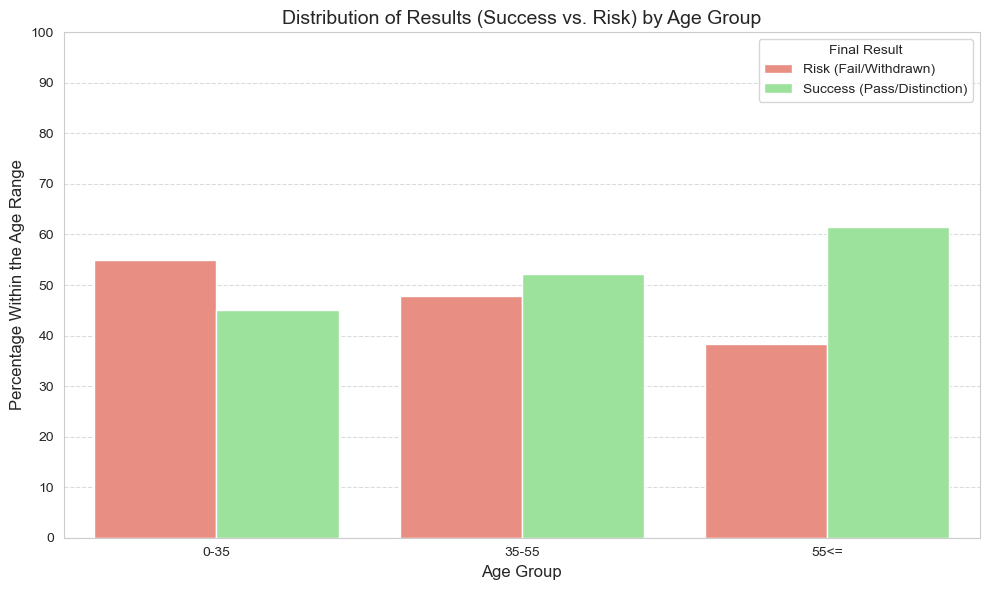

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Crear el gráfico de barras agrupadas y normalizadas (Agrupadas)
sns.barplot(
    data=df_age_counts,
    x='age_band',             # Franja de edad en el eje X
    y='percentage',           # Porcentaje en el eje Y
    hue='Result',          # El color (hue) diferenciará Éxito vs. Riesgo
    palette={
        'Success (Pass/Distinction)': 'lightgreen', # Color para Éxito
        'Risk (Fail/Withdrawn)': 'salmon' # Color para Riesgo
    },
    order=sorted(df_base['age_band'].unique()) # Opcional: ordenar las bandas lógicamente 
)

# Etiquetas y título
plt.title('Distribution of Results (Success vs. Risk) by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Percentage Within the Age Range', fontsize=12)
plt.yticks(range(0, 101, 10))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Final Result')
plt.tight_layout()
plt.show()

Visualización: Tasa de riesgo por (activity_type)

* Objetivo: Determinar si ciertas actividades (activity_type) presentan una tasa de riesgo significativamente mayor o menor que otras, lo que indicaría una relación entre la actividad y el éxito académico.


1. Preparación de datos (Cálculo de proporciones)

Combinamos df_base con df_vel para obtener la proporción de actividades y contabilizamos los valores de éxito/riesgo por actividad.

Necesitamos calcular, para cada actividad, el porcentaje de estudiantes en las clases de 'Risk' (0) y 'Success' (1).

In [39]:
# 1. Unir los tipos de actividades (df_vle) con el resultado final (risk_class)
df_activities = df_vle.merge(
    df_base[['id_student', 'code_module', 'code_presentation', 'risk_class']],
    on=['code_module', 'code_presentation'],
    how='left'
)

In [107]:
# 1. Borrar las columnas con valores nulos 
df_activities.drop(['week_from', 'week_to'], axis=1, inplace=True)

In [108]:
# 1. Calcular el conteo de Éxito/Riesgo por Tipo de actividad
df_activ_counts = df_activities.groupby(['activity_type', 'risk_class']).size().reset_index(name='count')

# 2. Calcular la proporción (Normalización) dentro de cada tipo de actividad
# Esto asegura que estamos comparando porcentajes, no conteos absolutos.
df_activ_counts['total_por_banda'] = df_activ_counts.groupby('activity_type')['count'].transform('sum')

# 3. Calcular el porcentaje
df_activ_counts['percentage'] = (df_activ_counts['count'] / df_activ_counts['total_por_banda'])*100

# 4. Asignar etiquetas claras para la visualización
df_activ_counts['Result'] = df_activ_counts['risk_class'].map({
    1: 'Success (Pass/Distinction)', 
    0: 'Risk (Fail/Withdrawn)'
})

2. Creación del gráfico de barras normalizado

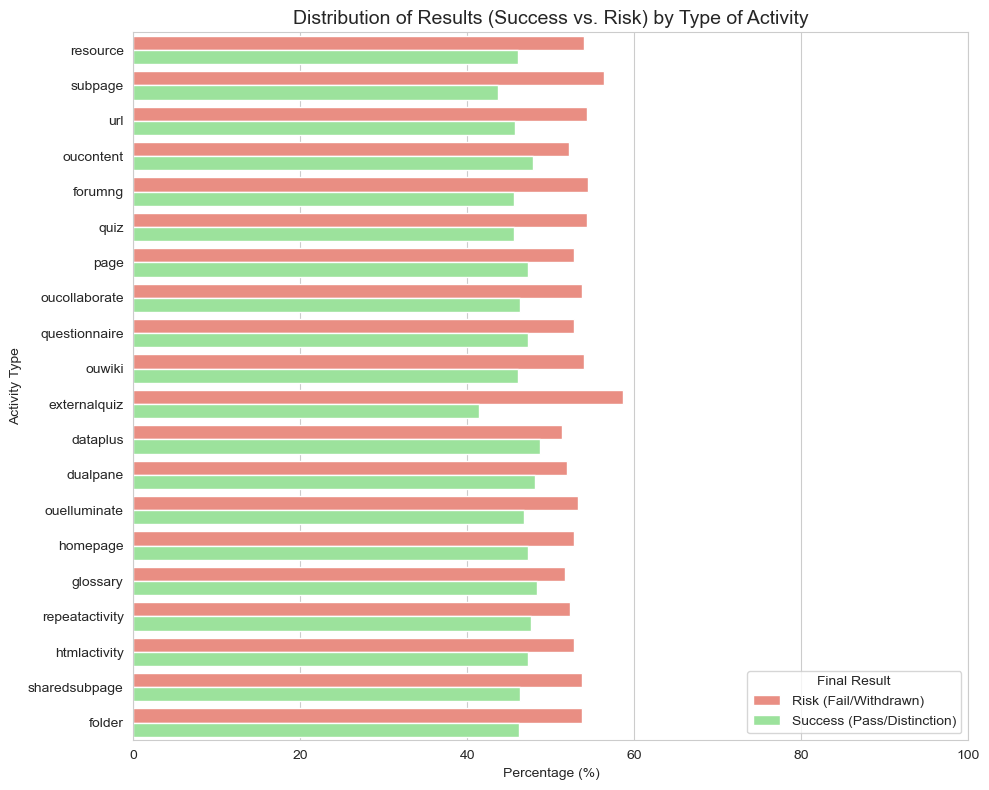

In [111]:
# Sort data by total count to show most frequent activities first
data = df_activ_counts.sort_values('count', ascending=False)

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(10, 8))

# Create a grouped bar plot
sns.barplot(
    data=data,
    x="percentage",
    y="activity_type",
    hue='Result',
    palette={
        'Success (Pass/Distinction)': 'lightgreen',
        'Risk (Fail/Withdrawn)': 'salmon'
    },
    ax=ax
)

# Add labels and formatting
ax.set(xlim=(0, 100), ylabel="Activity Type",
       xlabel="Percentage (%)")
ax.set_title("Distribution of Results (Success vs. Risk) by Type of Activity", fontsize=14)
ax.legend(title='Final Result', loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

---------------------------------------------------------------------------------------------------------------------

In [110]:
print(df_base['risk_class'].value_counts(normalize=True))

risk_class
0.0    0.527966
1.0    0.472034
Name: proportion, dtype: float64


In [106]:
# 1. Verificar la distribución absoluta y relativa de la clasificación final
# Asumiendo que df_base contiene la columna 'risk_class'
print("--- Conteo Absoluto de la Clase de Riesgo ---")
print(df_base['risk_class'].value_counts())

print("\n--- Porcentaje Relativo de la Clase de Riesgo ---")
print(df_base['risk_class'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

--- Conteo Absoluto de la Clase de Riesgo ---
risk_class
0.0    17208
1.0    15385
Name: count, dtype: int64

--- Porcentaje Relativo de la Clase de Riesgo ---
risk_class
0.0    52.8%
1.0    47.2%
Name: proportion, dtype: object


Análisis de la Distribución de Riesgo Base

El análisis de la base de datos df_base muestra la siguiente distribución global:

Riesgo (Clase 0): 52.8% (17,208 estudiantes)

Éxito (Clase 1): 47.2% (15,385 estudiantes)

---------------------------------------------------------------------------------------------------------------------